In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

In [ ]:
data = fetch_lfw_people(min_faces_per_person=70, resize=0.7)

In [ ]:
x,y = data.images[...,None], data.target
n_classes = len(data.target_names)
print("Cantidad de targets", n_classes)
print("Lista de nombres:",data.target_names)


Cantidad de targets 7
Lista de nombres: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


(87, 65, 1)


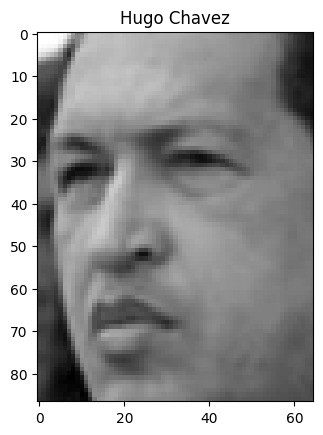

In [ ]:
plt.imshow(x[0], cmap = "gray")
plt.title(data.target_names[y[0]])
print(x[0].shape)

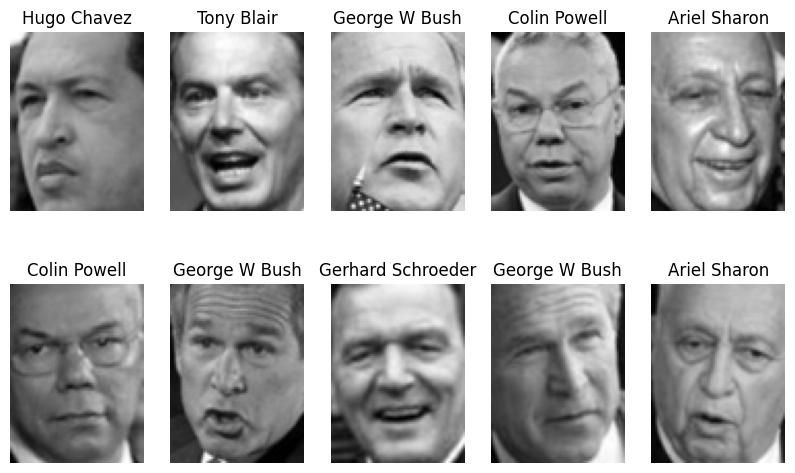

In [ ]:
plt.figure(figsize=(10,6))
for i in range(10):
  plt.subplot(2,5, i +1)
  plt.imshow(x[i], cmap = "gray")
  plt.title(data.target_names[y[i]])
  plt.axis("off")


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=x.shape[1:]),
    tf.keras.layers.Conv2D(32, 3, activation="relu"), #DEVUELVE UN MAPA DE CARACTERÍSTICAS
    tf.keras.layers.MaxPooling2D(), #reducir el mapa de características
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 85, 63, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 42, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 17920)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,293,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,313,607 (8.83 MB)

 Trainable params: 2,313,607 (8.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#OJO EXPLORANDO LA FORMA DE LAS IMAGENES
x.shape[1:]

(87, 65, 1)

In [ ]:
model.compile(optimizer ="adam", loss = "sparse_categorical_crossentropy")

In [ ]:
model.fit(x_train, y_train, epochs= 20)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 1.7289
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.5680
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1588
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7610
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5194
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3638
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2676
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2011
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1458
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0863
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0628
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0402
Epoch 13/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0239
Epoch 14/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0175
Epoch 15/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0135
Epoch 16/20


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Etiqueta real 1
Predicciòn del modelo [1]


Text(0.5, 1.0, "['Colin Powell']")

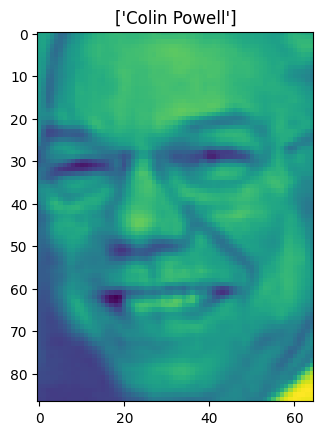

In [ ]:
indice = 20
prediccion = model.predict(x_test[[indice]]).argmax(1)
print("Etiqueta real", y_test[indice])
print("Predicciòn del modelo", prediccion)
plt.imshow(x_test[indice])
plt.title(data.target_names[prediccion])